# Fixed-Income Risk

This notebook extends the market-risk engine by replacing the simple
government-bond return proxy with an instrument-level fixed-income risk
framework.

The analysis includes:

- Fixed-rate bond pricing
- Macaulay duration
- Modified duration
- Convexity
- DV01
- Yield-shock P&L
- Parallel and non-parallel curve stresses
- Key-rate duration
- Historical yield-curve scenarios
- Fixed-income VaR

The objective is to measure both the level and the source of interest-rate
risk within the portfolio.

In [47]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import norm

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
CHARTS_DIR = PROJECT_ROOT / "outputs" / "charts"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\Pranav\Desktop\market-risk-engine


## 1. Treasury yield-curve data

Daily U.S. Treasury constant-maturity yields are used as benchmark
interest-rate risk factors.

The curve contains:

- 1-year
- 2-year
- 5-year
- 10-year
- 30-year

The Treasury curve is used as a benchmark risk-factor curve. Later sections
use these nodes to construct parallel and non-parallel interest-rate shocks.

In [48]:
FRED_SERIES = {
    "DGS1": "1Y",
    "DGS2": "2Y",
    "DGS5": "5Y",
    "DGS10": "10Y",
    "DGS30": "30Y",
}


def download_fred_series(series_id: str) -> pd.Series:
    """
    Download one FRED series directly as a pandas Series.
    """
    url = (
        "https://fred.stlouisfed.org/graph/"
        f"fredgraph.csv?id={series_id}"
    )

    data = pd.read_csv(url)

    date_column = data.columns[0]

    data[date_column] = pd.to_datetime(
        data[date_column]
    )

    data[series_id] = pd.to_numeric(
        data[series_id],
        errors="coerce",
    )

    series = (
        data
        .set_index(date_column)[series_id]
        .sort_index()
    )

    series.index.name = "date"

    return series

In [49]:
treasury_series = {}

for series_id, maturity_label in FRED_SERIES.items():
    print(
        f"Downloading {maturity_label} Treasury yield..."
    )

    treasury_series[maturity_label] = (
        download_fred_series(series_id)
    )

treasury_yields = pd.concat(
    treasury_series,
    axis=1,
)

# Convert percentage yields into decimals.
treasury_yields = treasury_yields / 100

treasury_yields = treasury_yields.dropna(
    how="all"
)

display(treasury_yields.tail())

,1Y,2Y,5Y,10Y,30Y
date,,,,,
2026-08-07,0.0401,0.0419,0.0435,0.0465,0.0519
2026-08-10,0.0404,0.0425,0.0441,0.0472,0.0525
2026-08-11,0.0403,0.0422,0.0439,0.0470,0.0524
2026-08-12,0.0400,0.0420,0.0438,0.0468,0.0524
2026-08-13,0.0397,0.0415,0.0432,0.0463,0.0521


In [50]:
treasury_yields_complete = (
    treasury_yields
    .dropna()
    .copy()
)

assert not treasury_yields_complete.empty

assert treasury_yields_complete.index.is_monotonic_increasing

assert not treasury_yields_complete.index.duplicated().any()

assert not treasury_yields_complete.isna().any().any()

assert np.isfinite(
    treasury_yields_complete.to_numpy()
).all()

print(
    f"Complete curve observations: "
    f"{len(treasury_yields_complete):,}"
)

print(
    f"Sample: "
    f"{treasury_yields_complete.index.min().date()} "
    f"to "
    f"{treasury_yields_complete.index.max().date()}"
)

print(
    f"Latest complete curve date: "
    f"{treasury_yields_complete.index[-1].date()}"
)

Complete curve observations: 12,369
Sample: 1977-02-15 to 2026-08-13
Latest complete curve date: 2026-08-13


In [51]:
treasury_yields_complete.to_csv(
    PROCESSED_DATA_DIR
    / "treasury_constant_maturity_yields.csv"
)

print("Treasury yield data saved.")

Treasury yield data saved.


In [52]:
latest_curve_date = (
    treasury_yields_complete.index[-1]
)

latest_curve = (
    treasury_yields_complete
    .loc[latest_curve_date]
)

latest_curve_table = (
    latest_curve
    .rename("yield")
    .to_frame()
)

display(
    latest_curve_table.style.format(
        {
            "yield": "{:.3%}",
        }
    )
)

,yield
1Y,3.970%
2Y,4.150%
5Y,4.320%
10Y,4.630%
30Y,5.210%


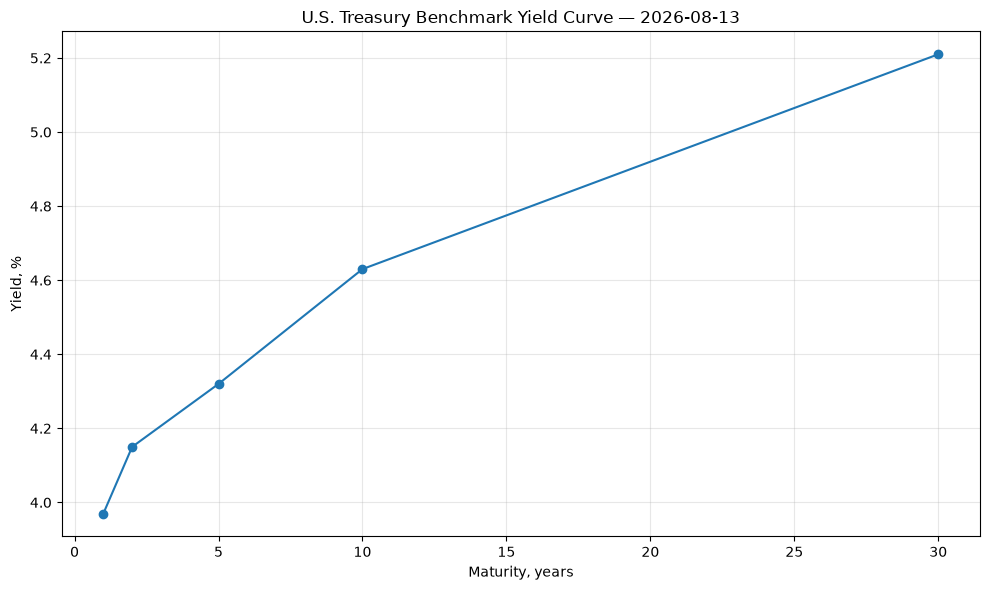

In [53]:
CURVE_MATURITIES = pd.Series(
    {
        "1Y": 1,
        "2Y": 2,
        "5Y": 5,
        "10Y": 10,
        "30Y": 30,
    }
)

fig_current_curve, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    CURVE_MATURITIES.values,
    latest_curve.reindex(
        CURVE_MATURITIES.index
    ).values * 100,
    marker="o",
)

ax.set_title(
    f"U.S. Treasury Benchmark Yield Curve — "
    f"{latest_curve_date.date()}"
)

ax.set_xlabel("Maturity, years")
ax.set_ylabel("Yield, %")

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
bond_portfolio = pd.DataFrame(
    {
        "bond": [
            "2Y Treasury",
            "5Y Treasury",
            "10Y Treasury",
        ],
        "maturity_years": [
            2.0,
            5.0,
            10.0,
        ],
        "coupon_rate": [
            0.0400,
            0.0425,
            0.0450,
        ],
        "face_value_eur": [
            100_000,
            100_000,
            100_000,
        ],
        "payments_per_year": [
            2,
            2,
            2,
        ],
        "curve_node": [
            "2Y",
            "5Y",
            "10Y",
        ],
    }
)

assert np.isclose(
    bond_portfolio["face_value_eur"].sum(),
    300_000,
)

display(
    bond_portfolio.style.format(
        {
            "maturity_years": "{:.1f}",
            "coupon_rate": "{:.2%}",
            "face_value_eur": "EUR {:,.0f}",
        }
    )
)

,bond,maturity_years,coupon_rate,face_value_eur,payments_per_year,curve_node
0,2Y Treasury,2.0,4.00%,"EUR 100,000",2,2Y
1,5Y Treasury,5.0,4.25%,"EUR 100,000",2,5Y
2,10Y Treasury,10.0,4.50%,"EUR 100,000",2,10Y


## 2. Fixed-income subportfolio

The original EUR 300,000 government-bond exposure is replaced with an
illustrative three-bond portfolio.

Each bond is exposed to a different point on the Treasury curve. This allows
interest-rate risk to be analysed by maturity rather than treating the entire
fixed-income allocation as one return series.

The current implementation uses Treasury yields as benchmark rate factors and
reports instrument values in EUR-equivalent portfolio units. Separate foreign-
exchange translation remains outside the fixed-income module.

In [55]:
def price_fixed_coupon_bond(
    face_value: float,
    coupon_rate: float,
    maturity_years: float,
    yield_to_maturity: float,
    payments_per_year: int = 2,
) -> float:
    """
    Price a fixed-rate coupon bond using yield-to-maturity discounting.
    """
    if face_value <= 0:
        raise ValueError(
            "face_value must be positive."
        )

    if maturity_years <= 0:
        raise ValueError(
            "maturity_years must be positive."
        )

    if payments_per_year <= 0:
        raise ValueError(
            "payments_per_year must be positive."
        )

    number_of_periods = int(
        round(
            maturity_years
            * payments_per_year
        )
    )

    periodic_yield = (
        yield_to_maturity
        / payments_per_year
    )

    coupon_payment = (
        face_value
        * coupon_rate
        / payments_per_year
    )

    periods = np.arange(
        1,
        number_of_periods + 1,
    )

    cash_flows = np.full(
        number_of_periods,
        coupon_payment,
        dtype=float,
    )

    cash_flows[-1] += face_value

    discount_factors = (
        1 + periodic_yield
    ) ** periods

    price = np.sum(
        cash_flows
        / discount_factors
    )

    return float(price)

## 3. Duration, convexity and DV01

Macaulay duration measures the present-value-weighted average timing of bond
cash flows.

Modified duration measures the approximate percentage change in bond price for
a small change in yield:

\[
\frac{\Delta P}{P}
\approx
-D_{mod}\Delta y.
\]

DV01 converts this sensitivity into currency terms and measures the approximate
change in bond value for a one-basis-point change in yield.

Convexity captures the curvature that duration alone ignores:

\[
\frac{\Delta P}{P}
\approx
-D_{mod}\Delta y
+
\frac{1}{2}Convexity(\Delta y)^2.
\]

In [56]:
def calculate_bond_risk_metrics(
    face_value: float,
    coupon_rate: float,
    maturity_years: float,
    yield_to_maturity: float,
    payments_per_year: int = 2,
) -> dict:
    """
    Calculate price, duration, convexity and DV01 for a fixed-rate bond.
    """
    number_of_periods = int(
        round(
            maturity_years
            * payments_per_year
        )
    )

    periodic_yield = (
        yield_to_maturity
        / payments_per_year
    )

    coupon_payment = (
        face_value
        * coupon_rate
        / payments_per_year
    )

    periods = np.arange(
        1,
        number_of_periods + 1,
        dtype=float,
    )

    cash_flows = np.full(
        number_of_periods,
        coupon_payment,
        dtype=float,
    )

    cash_flows[-1] += face_value

    discount_factors = (
        1 + periodic_yield
    ) ** periods

    present_values = (
        cash_flows
        / discount_factors
    )

    price = float(
        present_values.sum()
    )

    times_years = (
        periods
        / payments_per_year
    )

    macaulay_duration = float(
        np.sum(
            times_years
            * present_values
        )
        / price
    )

    modified_duration = (
        macaulay_duration
        / (
            1
            + yield_to_maturity
            / payments_per_year
        )
    )

    convexity = float(
        np.sum(
            cash_flows
            * periods
            * (periods + 1)
            / (
                (
                    1 + periodic_yield
                )
                ** (periods + 2)
            )
        )
        / (
            price
            * payments_per_year**2
        )
    )

    approximate_dv01 = (
        modified_duration
        * price
        * 0.0001
    )

    bump = 0.0001

    price_yield_down = price_fixed_coupon_bond(
        face_value=face_value,
        coupon_rate=coupon_rate,
        maturity_years=maturity_years,
        yield_to_maturity=(
            yield_to_maturity - bump
        ),
        payments_per_year=payments_per_year,
    )

    price_yield_up = price_fixed_coupon_bond(
        face_value=face_value,
        coupon_rate=coupon_rate,
        maturity_years=maturity_years,
        yield_to_maturity=(
            yield_to_maturity + bump
        ),
        payments_per_year=payments_per_year,
    )

    exact_dv01 = (
        price_yield_down
        - price_yield_up
    ) / 2

    return {
        "price_eur": price,
        "macaulay_duration": macaulay_duration,
        "modified_duration": modified_duration,
        "convexity": convexity,
        "approximate_dv01_eur": approximate_dv01,
        "exact_dv01_eur": exact_dv01,
    }

In [57]:
bond_risk_records = []

for row in bond_portfolio.itertuples():
    benchmark_yield = float(
        latest_curve.loc[
            row.curve_node
        ]
    )

    metrics = calculate_bond_risk_metrics(
        face_value=row.face_value_eur,
        coupon_rate=row.coupon_rate,
        maturity_years=row.maturity_years,
        yield_to_maturity=benchmark_yield,
        payments_per_year=row.payments_per_year,
    )

    bond_risk_records.append(
        {
            "bond": row.bond,
            "curve_node": row.curve_node,
            "benchmark_yield": benchmark_yield,
            "face_value_eur": row.face_value_eur,
            "coupon_rate": row.coupon_rate,
            **metrics,
        }
    )

bond_risk_results = (
    pd.DataFrame(
        bond_risk_records
    )
    .set_index("bond")
)

display(
    bond_risk_results.style.format(
        {
            "benchmark_yield": "{:.3%}",
            "face_value_eur": "EUR {:,.0f}",
            "coupon_rate": "{:.2%}",
            "price_eur": "EUR {:,.2f}",
            "macaulay_duration": "{:.3f}",
            "modified_duration": "{:.3f}",
            "convexity": "{:.3f}",
            "approximate_dv01_eur": "EUR {:,.2f}",
            "exact_dv01_eur": "EUR {:,.2f}",
        }
    )
)

,curve_node,benchmark_yield,face_value_eur,coupon_rate,price_eur,macaulay_duration,modified_duration,convexity,approximate_dv01_eur,exact_dv01_eur
bond,,,,,,,,,,
2Y Treasury,2Y,4.150%,"EUR 100,000",4.00%,"EUR 99,714.94",1.942,1.902,4.613,EUR 18.97,EUR 18.97
5Y Treasury,5Y,4.320%,"EUR 100,000",4.25%,"EUR 99,688.23",4.556,4.460,23.252,EUR 44.46,EUR 44.46
10Y Treasury,10Y,4.630%,"EUR 100,000",4.50%,"EUR 98,968.77",8.150,7.966,75.973,EUR 78.83,EUR 78.83


In [58]:
fixed_income_market_value = (
    bond_risk_results[
        "price_eur"
    ].sum()
)

fixed_income_dv01 = (
    bond_risk_results[
        "exact_dv01_eur"
    ].sum()
)

weighted_modified_duration = (
    (
        bond_risk_results[
            "price_eur"
        ]
        * bond_risk_results[
            "modified_duration"
        ]
    ).sum()
    / fixed_income_market_value
)

weighted_convexity = (
    (
        bond_risk_results[
            "price_eur"
        ]
        * bond_risk_results[
            "convexity"
        ]
    ).sum()
    / fixed_income_market_value
)

fixed_income_summary = pd.DataFrame(
    {
        "metric": [
            "Market value",
            "Portfolio modified duration",
            "Portfolio convexity",
            "Portfolio DV01",
        ],
        "value": [
            fixed_income_market_value,
            weighted_modified_duration,
            weighted_convexity,
            fixed_income_dv01,
        ],
    }
)

display(fixed_income_summary)

,metric,value
0,Market value,298371.934095
1,Portfolio modified duration,4.767942
2,Portfolio convexity,34.510069
3,Portfolio DV01,142.262016


In [59]:
print(
    f"Fixed-income market value: "
    f"EUR {fixed_income_market_value:,.2f}"
)

print(
    f"Portfolio modified duration: "
    f"{weighted_modified_duration:.3f} years"
)

print(
    f"Portfolio convexity: "
    f"{weighted_convexity:.3f}"
)

print(
    f"Portfolio DV01: "
    f"EUR {fixed_income_dv01:,.2f}"
)

Fixed-income market value: EUR 298,371.93
Portfolio modified duration: 4.768 years
Portfolio convexity: 34.510
Portfolio DV01: EUR 142.26


In [60]:
dv01_contribution = pd.DataFrame(
    {
        "market_value_eur": (
            bond_risk_results[
                "price_eur"
            ]
        ),
        "modified_duration": (
            bond_risk_results[
                "modified_duration"
            ]
        ),
        "dv01_eur": (
            bond_risk_results[
                "exact_dv01_eur"
            ]
        ),
    }
)

dv01_contribution[
    "dv01_share"
] = (
    dv01_contribution[
        "dv01_eur"
    ]
    / fixed_income_dv01
)

display(
    dv01_contribution.style.format(
        {
            "market_value_eur": "EUR {:,.2f}",
            "modified_duration": "{:.3f}",
            "dv01_eur": "EUR {:,.2f}",
            "dv01_share": "{:.2%}",
        }
    )
)

,market_value_eur,modified_duration,dv01_eur,dv01_share
bond,,,,
2Y Treasury,"EUR 99,714.94",1.902,EUR 18.97,13.33%
5Y Treasury,"EUR 99,688.23",4.460,EUR 44.46,31.25%
10Y Treasury,"EUR 98,968.77",7.966,EUR 78.83,55.42%


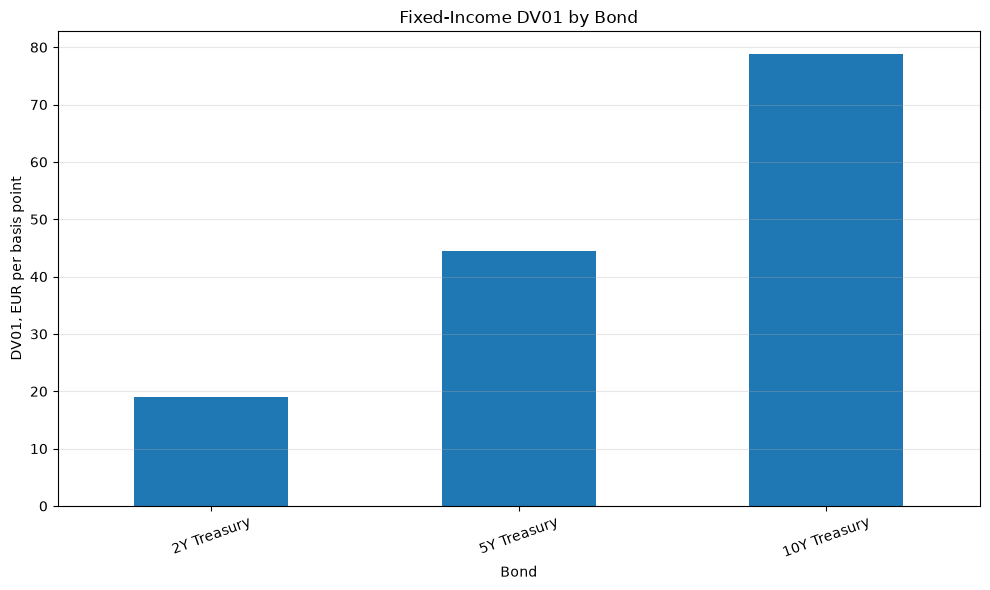

In [61]:
fig_dv01, ax = plt.subplots(
    figsize=(10, 6)
)

dv01_contribution[
    "dv01_eur"
].plot(
    kind="bar",
    ax=ax,
)

ax.set_title(
    "Fixed-Income DV01 by Bond"
)

ax.set_xlabel("Bond")
ax.set_ylabel("DV01, EUR per basis point")

ax.tick_params(
    axis="x",
    rotation=20,
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [62]:
latest_curve_table.to_csv(
    TABLES_DIR
    / "current_treasury_yield_curve.csv"
)

bond_risk_results.to_csv(
    TABLES_DIR
    / "bond_risk_metrics.csv"
)

dv01_contribution.to_csv(
    TABLES_DIR
    / "bond_dv01_contributions.csv"
)

fig_current_curve.savefig(
    CHARTS_DIR
    / "current_treasury_yield_curve.png",
    dpi=300,
    bbox_inches="tight",
)

fig_dv01.savefig(
    CHARTS_DIR
    / "bond_dv01_contributions.png",
    dpi=300,
    bbox_inches="tight",
)

print("Initial Day 5 fixed-income outputs saved.")

Initial Day 5 fixed-income outputs saved.


## 4. Parallel yield-curve stress testing

A parallel yield-curve shock assumes that all benchmark yields move by the
same number of basis points.

Three approaches are compared:

1. Duration-only approximation
2. Duration-convexity approximation
3. Exact full revaluation

The duration approximation is:

\[
\Delta P
\approx
-PD_{mod}\Delta y.
\]

Adding convexity gives:

\[
\Delta P
\approx
P
\left[
-D_{mod}\Delta y
+
\frac{1}{2}C(\Delta y)^2
\right].
\]

For larger interest-rate shocks, full repricing provides the benchmark against
which the approximations can be evaluated.

In [63]:
PARALLEL_SHOCKS_BPS = [
    -200,
    -100,
    -50,
    -25,
    25,
    50,
    100,
    200,
]

print("Parallel yield shocks:")
print(PARALLEL_SHOCKS_BPS)

Parallel yield shocks:
[-200, -100, -50, -25, 25, 50, 100, 200]


In [64]:
def calculate_bond_shock_pnl(
    face_value: float,
    coupon_rate: float,
    maturity_years: float,
    base_yield: float,
    shock_bps: float,
    payments_per_year: int = 2,
) -> dict:
    """
    Compare duration, duration-convexity and exact repricing
    for a parallel yield shock.
    """
    base_metrics = calculate_bond_risk_metrics(
        face_value=face_value,
        coupon_rate=coupon_rate,
        maturity_years=maturity_years,
        yield_to_maturity=base_yield,
        payments_per_year=payments_per_year,
    )

    base_price = base_metrics["price_eur"]
    modified_duration = base_metrics["modified_duration"]
    convexity = base_metrics["convexity"]

    yield_change = shock_bps / 10_000

    shocked_yield = base_yield + yield_change

    if shocked_yield <= -payments_per_year:
        raise ValueError(
            "The shocked yield is outside the valid pricing range."
        )

    shocked_price = price_fixed_coupon_bond(
        face_value=face_value,
        coupon_rate=coupon_rate,
        maturity_years=maturity_years,
        yield_to_maturity=shocked_yield,
        payments_per_year=payments_per_year,
    )

    exact_pnl = (
        shocked_price
        - base_price
    )

    duration_pnl = (
        -modified_duration
        * base_price
        * yield_change
    )

    duration_convexity_pnl = (
        base_price
        * (
            -modified_duration * yield_change
            + 0.5
            * convexity
            * yield_change**2
        )
    )

    return {
        "shock_bps": shock_bps,
        "base_yield": base_yield,
        "shocked_yield": shocked_yield,
        "base_price_eur": base_price,
        "shocked_price_eur": shocked_price,
        "duration_pnl_eur": duration_pnl,
        "duration_convexity_pnl_eur": (
            duration_convexity_pnl
        ),
        "exact_pnl_eur": exact_pnl,
        "duration_error_eur": (
            duration_pnl - exact_pnl
        ),
        "duration_convexity_error_eur": (
            duration_convexity_pnl
            - exact_pnl
        ),
    }

In [65]:
bond_shock_records = []

for row in bond_portfolio.itertuples():

    base_yield = float(
        latest_curve.loc[row.curve_node]
    )

    for shock_bps in PARALLEL_SHOCKS_BPS:

        result = calculate_bond_shock_pnl(
            face_value=row.face_value_eur,
            coupon_rate=row.coupon_rate,
            maturity_years=row.maturity_years,
            base_yield=base_yield,
            shock_bps=shock_bps,
            payments_per_year=row.payments_per_year,
        )

        bond_shock_records.append(
            {
                "bond": row.bond,
                "curve_node": row.curve_node,
                **result,
            }
        )

bond_parallel_shock_results = pd.DataFrame(
    bond_shock_records
)

display(
    bond_parallel_shock_results.head(10).style.format(
        {
            "shock_bps": "{:+.0f}",
            "base_yield": "{:.3%}",
            "shocked_yield": "{:.3%}",
            "base_price_eur": "EUR {:,.2f}",
            "shocked_price_eur": "EUR {:,.2f}",
            "duration_pnl_eur": "EUR {:+,.2f}",
            "duration_convexity_pnl_eur": "EUR {:+,.2f}",
            "exact_pnl_eur": "EUR {:+,.2f}",
            "duration_error_eur": "EUR {:+,.2f}",
            "duration_convexity_error_eur": "EUR {:+,.2f}",
        }
    )
)

,bond,curve_node,shock_bps,base_yield,shocked_yield,base_price_eur,shocked_price_eur,duration_pnl_eur,duration_convexity_pnl_eur,exact_pnl_eur,duration_error_eur,duration_convexity_error_eur
0,2Y Treasury,2Y,-200,4.150%,2.150%,"EUR 99,714.94","EUR 103,602.66","EUR +3,793.90","EUR +3,885.90","EUR +3,887.72",EUR -93.82,EUR -1.82
1,2Y Treasury,2Y,-100,4.150%,3.150%,"EUR 99,714.94","EUR 101,635.11","EUR +1,896.95","EUR +1,919.95","EUR +1,920.17",EUR -23.23,EUR -0.23
2,2Y Treasury,2Y,-50,4.150%,3.650%,"EUR 99,714.94","EUR 100,669.19",EUR +948.47,EUR +954.22,EUR +954.25,EUR -5.78,EUR -0.03
3,2Y Treasury,2Y,-25,4.150%,3.900%,"EUR 99,714.94","EUR 100,190.62",EUR +474.24,EUR +475.67,EUR +475.68,EUR -1.44,EUR -0.00
4,2Y Treasury,2Y,+25,4.150%,4.400%,"EUR 99,714.94","EUR 99,242.14",EUR -474.24,EUR -472.80,EUR -472.80,EUR -1.43,EUR +0.00
5,2Y Treasury,2Y,+50,4.150%,4.650%,"EUR 99,714.94","EUR 98,772.19",EUR -948.47,EUR -942.72,EUR -942.75,EUR -5.72,EUR +0.03
6,2Y Treasury,2Y,+100,4.150%,5.150%,"EUR 99,714.94","EUR 97,840.77","EUR -1,896.95","EUR -1,873.95","EUR -1,874.17",EUR -22.78,EUR +0.22
7,2Y Treasury,2Y,+200,4.150%,6.150%,"EUR 99,714.94","EUR 96,011.28","EUR -3,793.90","EUR -3,701.90","EUR -3,703.66",EUR -90.23,EUR +1.76
8,5Y Treasury,5Y,-200,4.320%,2.320%,"EUR 99,688.23","EUR 109,061.85","EUR +8,891.60","EUR +9,355.19","EUR +9,373.63",EUR -482.03,EUR -18.44
9,5Y Treasury,5Y,-100,4.320%,3.320%,"EUR 99,688.23","EUR 104,252.19","EUR +4,445.80","EUR +4,561.70","EUR +4,563.97",EUR -118.16,EUR -2.27


In [66]:
portfolio_parallel_shocks = (
    bond_parallel_shock_results
    .groupby("shock_bps")[
        [
            "duration_pnl_eur",
            "duration_convexity_pnl_eur",
            "exact_pnl_eur",
        ]
    ]
    .sum()
    .reset_index()
)

portfolio_parallel_shocks[
    "duration_error_eur"
] = (
    portfolio_parallel_shocks[
        "duration_pnl_eur"
    ]
    - portfolio_parallel_shocks[
        "exact_pnl_eur"
    ]
)

portfolio_parallel_shocks[
    "duration_convexity_error_eur"
] = (
    portfolio_parallel_shocks[
        "duration_convexity_pnl_eur"
    ]
    - portfolio_parallel_shocks[
        "exact_pnl_eur"
    ]
)

portfolio_parallel_shocks[
    "duration_absolute_error_eur"
] = (
    portfolio_parallel_shocks[
        "duration_error_eur"
    ].abs()
)

portfolio_parallel_shocks[
    "duration_convexity_absolute_error_eur"
] = (
    portfolio_parallel_shocks[
        "duration_convexity_error_eur"
    ].abs()
)

display(
    portfolio_parallel_shocks.style.format(
        {
            "shock_bps": "{:+.0f}",
            "duration_pnl_eur": "EUR {:+,.2f}",
            "duration_convexity_pnl_eur": "EUR {:+,.2f}",
            "exact_pnl_eur": "EUR {:+,.2f}",
            "duration_error_eur": "EUR {:+,.2f}",
            "duration_convexity_error_eur": "EUR {:+,.2f}",
            "duration_absolute_error_eur": "EUR {:,.2f}",
            "duration_convexity_absolute_error_eur": "EUR {:,.2f}",
        }
    )
)

,shock_bps,duration_pnl_eur,duration_convexity_pnl_eur,exact_pnl_eur,duration_error_eur,duration_convexity_error_eur,duration_absolute_error_eur,duration_convexity_absolute_error_eur
0,-200,"EUR +28,452.40","EUR +30,511.77","EUR +30,641.87","EUR -2,189.47",EUR -130.10,"EUR 2,189.47",EUR 130.10
1,-100,"EUR +14,226.20","EUR +14,741.04","EUR +14,756.88",EUR -530.68,EUR -15.84,EUR 530.68,EUR 15.84
2,-50,"EUR +7,113.10","EUR +7,241.81","EUR +7,243.77",EUR -130.67,EUR -1.95,EUR 130.67,EUR 1.95
3,-25,"EUR +3,556.55","EUR +3,588.73","EUR +3,588.97",EUR -32.42,EUR -0.24,EUR 32.42,EUR 0.24
4,+25,"EUR -3,556.55","EUR -3,524.37","EUR -3,524.61",EUR -31.94,EUR +0.24,EUR 31.94,EUR 0.24
5,+50,"EUR -7,113.10","EUR -6,984.39","EUR -6,986.30",EUR -126.80,EUR +1.91,EUR 126.80,EUR 1.91
6,+100,"EUR -14,226.20","EUR -13,711.36","EUR -13,726.41",EUR -499.79,EUR +15.05,EUR 499.79,EUR 15.05
7,+200,"EUR -28,452.40","EUR -26,393.03","EUR -26,510.51","EUR -1,941.89",EUR +117.48,"EUR 1,941.89",EUR 117.48


In [67]:
approximation_error_summary = pd.DataFrame(
    {
        "method": [
            "Duration only",
            "Duration + convexity",
        ],
        "mean_absolute_error_eur": [
            portfolio_parallel_shocks[
                "duration_absolute_error_eur"
            ].mean(),
            portfolio_parallel_shocks[
                "duration_convexity_absolute_error_eur"
            ].mean(),
        ],
        "maximum_absolute_error_eur": [
            portfolio_parallel_shocks[
                "duration_absolute_error_eur"
            ].max(),
            portfolio_parallel_shocks[
                "duration_convexity_absolute_error_eur"
            ].max(),
        ],
    }
)

display(
    approximation_error_summary.style.format(
        {
            "mean_absolute_error_eur": "EUR {:,.2f}",
            "maximum_absolute_error_eur": "EUR {:,.2f}",
        }
    )
)

,method,mean_absolute_error_eur,maximum_absolute_error_eur
0,Duration only,EUR 685.46,"EUR 2,189.47"
1,Duration + convexity,EUR 35.35,EUR 130.10


In [68]:
plus_100bp_result = (
    portfolio_parallel_shocks.loc[
        portfolio_parallel_shocks[
            "shock_bps"
        ] == 100
    ]
)

display(
    plus_100bp_result.style.format(
        {
            "shock_bps": "{:+.0f}",
            "duration_pnl_eur": "EUR {:+,.2f}",
            "duration_convexity_pnl_eur": "EUR {:+,.2f}",
            "exact_pnl_eur": "EUR {:+,.2f}",
            "duration_error_eur": "EUR {:+,.2f}",
            "duration_convexity_error_eur": "EUR {:+,.2f}",
        }
    )
)

,shock_bps,duration_pnl_eur,duration_convexity_pnl_eur,exact_pnl_eur,duration_error_eur,duration_convexity_error_eur,duration_absolute_error_eur,duration_convexity_absolute_error_eur
6,+100,"EUR -14,226.20","EUR -13,711.36","EUR -13,726.41",EUR -499.79,EUR +15.05,499.788392,15.053407


In [69]:
plus_100bp_exact_pnl = float(
    plus_100bp_result[
        "exact_pnl_eur"
    ].iloc[0]
)

plus_100bp_loss_pct = (
    plus_100bp_exact_pnl
    / fixed_income_market_value
)

print(
    f"Exact P&L under +100 bp parallel shock: "
    f"EUR {plus_100bp_exact_pnl:+,.2f}"
)

print(
    f"Percentage of fixed-income market value: "
    f"{plus_100bp_loss_pct:+.2%}"
)

Exact P&L under +100 bp parallel shock: EUR -13,726.41
Percentage of fixed-income market value: -4.60%


In [70]:
plus_100bp_bond_results = (
    bond_parallel_shock_results.loc[
        bond_parallel_shock_results[
            "shock_bps"
        ] == 100
    ]
    .set_index("bond")
    .copy()
)

total_plus_100bp_loss = (
    plus_100bp_bond_results[
        "exact_pnl_eur"
    ].sum()
)

plus_100bp_bond_results[
    "loss_contribution_pct"
] = (
    plus_100bp_bond_results[
        "exact_pnl_eur"
    ]
    / total_plus_100bp_loss
)

display(
    plus_100bp_bond_results[
        [
            "curve_node",
            "base_yield",
            "shocked_yield",
            "exact_pnl_eur",
            "loss_contribution_pct",
        ]
    ].style.format(
        {
            "base_yield": "{:.3%}",
            "shocked_yield": "{:.3%}",
            "exact_pnl_eur": "EUR {:+,.2f}",
            "loss_contribution_pct": "{:.2%}",
        }
    )
)

,curve_node,base_yield,shocked_yield,exact_pnl_eur,loss_contribution_pct
bond,,,,,
2Y Treasury,2Y,4.150%,5.150%,"EUR -1,874.17",13.65%
5Y Treasury,5Y,4.320%,5.320%,"EUR -4,332.10",31.56%
10Y Treasury,10Y,4.630%,5.630%,"EUR -7,520.14",54.79%


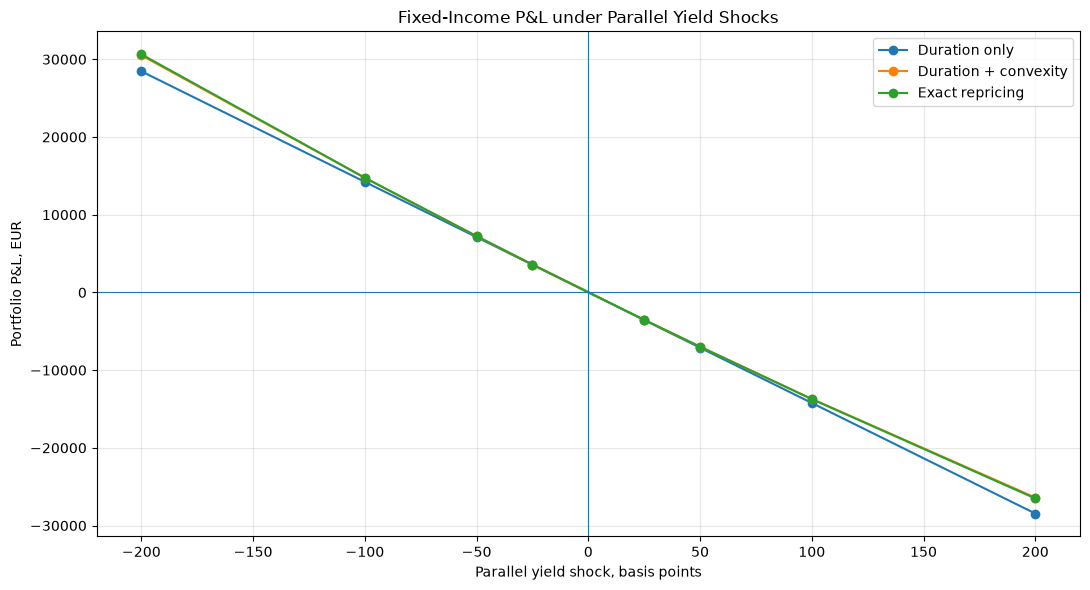

In [71]:
fig_parallel_stress, ax = plt.subplots(
    figsize=(11, 6)
)

ax.plot(
    portfolio_parallel_shocks["shock_bps"],
    portfolio_parallel_shocks["duration_pnl_eur"],
    marker="o",
    label="Duration only",
)

ax.plot(
    portfolio_parallel_shocks["shock_bps"],
    portfolio_parallel_shocks[
        "duration_convexity_pnl_eur"
    ],
    marker="o",
    label="Duration + convexity",
)

ax.plot(
    portfolio_parallel_shocks["shock_bps"],
    portfolio_parallel_shocks["exact_pnl_eur"],
    marker="o",
    label="Exact repricing",
)

ax.axhline(
    0,
    linewidth=0.8,
)

ax.axvline(
    0,
    linewidth=0.8,
)

ax.set_title(
    "Fixed-Income P&L under Parallel Yield Shocks"
)

ax.set_xlabel("Parallel yield shock, basis points")
ax.set_ylabel("Portfolio P&L, EUR")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

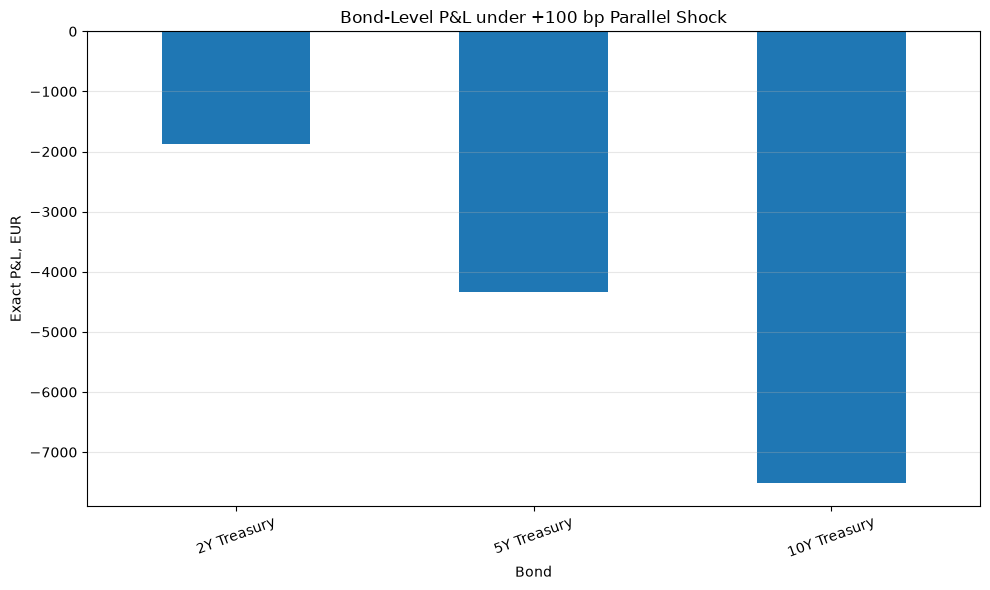

In [72]:
fig_100bp_contribution, ax = plt.subplots(
    figsize=(10, 6)
)

plus_100bp_bond_results[
    "exact_pnl_eur"
].plot(
    kind="bar",
    ax=ax,
)

ax.axhline(
    0,
    linewidth=0.8,
)

ax.set_title(
    "Bond-Level P&L under +100 bp Parallel Shock"
)

ax.set_xlabel("Bond")
ax.set_ylabel("Exact P&L, EUR")

ax.tick_params(
    axis="x",
    rotation=20,
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [73]:
bond_parallel_shock_results.to_csv(
    TABLES_DIR
    / "bond_parallel_yield_shocks.csv",
    index=False,
)

portfolio_parallel_shocks.to_csv(
    TABLES_DIR
    / "portfolio_parallel_yield_shocks.csv",
    index=False,
)

approximation_error_summary.to_csv(
    TABLES_DIR
    / "duration_approximation_errors.csv",
    index=False,
)

plus_100bp_bond_results.to_csv(
    TABLES_DIR
    / "plus_100bp_bond_contributions.csv",
    index=True,
)

fig_parallel_stress.savefig(
    CHARTS_DIR
    / "parallel_yield_shock_pnl.png",
    dpi=300,
    bbox_inches="tight",
)

fig_100bp_contribution.savefig(
    CHARTS_DIR
    / "plus_100bp_bond_loss_contributions.png",
    dpi=300,
    bbox_inches="tight",
)

print(
    "Parallel yield-shock analysis saved."
)

Parallel yield-shock analysis saved.


### Parallel yield-shock interpretation

The fixed-income portfolio exhibits substantial maturity concentration.

Under a +100 basis-point parallel increase in Treasury yields, exact full
revaluation produces a portfolio loss of approximately EUR 13,726.

Although each bond has the same EUR 100,000 face value, the 10-year bond
contributes approximately 54.8% of the total loss. The 5-year bond contributes
approximately 31.6%, while the 2-year bond contributes only approximately
13.7%.

The result demonstrates that fixed-income risk is determined by interest-rate
sensitivity rather than notional exposure alone.

Duration provides a reasonable approximation for small yield movements but
becomes increasingly inaccurate for larger shocks because the price-yield
relationship is nonlinear.

Across the tested scenarios, the duration-only approximation has a mean
absolute error of approximately EUR 685. Adding convexity reduces the mean
absolute error to approximately EUR 35.

Duration-convexity therefore provides a substantially more accurate
approximation of full revaluation, particularly under large yield shocks.

## 5. Key-rate interest-rate risk

Portfolio DV01 measures sensitivity to a parallel one-basis-point yield shift,
but it does not identify where along the yield curve that sensitivity occurs.

Key-rate DV01 measures the change in portfolio value when an individual
maturity point moves by one basis point while the other curve nodes remain
unchanged.

For the illustrative bond portfolio, the main key-rate nodes are:

- 2-year
- 5-year
- 10-year

The sum of key-rate DV01s approximates the portfolio's parallel DV01.

In [74]:
KEY_RATE_NODES = [
    "2Y",
    "5Y",
    "10Y",
]

key_rate_dv01_records = []

for node in KEY_RATE_NODES:

    node_dv01 = 0.0

    for row in bond_portfolio.itertuples():

        if row.curve_node != node:
            continue

        base_yield = float(
            latest_curve.loc[row.curve_node]
        )

        bump = 0.0001

        price_down = price_fixed_coupon_bond(
            face_value=row.face_value_eur,
            coupon_rate=row.coupon_rate,
            maturity_years=row.maturity_years,
            yield_to_maturity=base_yield - bump,
            payments_per_year=row.payments_per_year,
        )

        price_up = price_fixed_coupon_bond(
            face_value=row.face_value_eur,
            coupon_rate=row.coupon_rate,
            maturity_years=row.maturity_years,
            yield_to_maturity=base_yield + bump,
            payments_per_year=row.payments_per_year,
        )

        dv01 = (
            price_down - price_up
        ) / 2

        node_dv01 += dv01

    key_rate_dv01_records.append(
        {
            "curve_node": node,
            "key_rate_dv01_eur": node_dv01,
        }
    )

key_rate_dv01 = (
    pd.DataFrame(key_rate_dv01_records)
    .set_index("curve_node")
)

key_rate_dv01[
    "key_rate_dv01_share"
] = (
    key_rate_dv01["key_rate_dv01_eur"]
    / key_rate_dv01[
        "key_rate_dv01_eur"
    ].sum()
)

display(
    key_rate_dv01.style.format(
        {
            "key_rate_dv01_eur": "EUR {:,.2f}",
            "key_rate_dv01_share": "{:.2%}",
        }
    )
)

,key_rate_dv01_eur,key_rate_dv01_share
curve_node,,
2Y,EUR 18.97,13.33%
5Y,EUR 44.46,31.25%
10Y,EUR 78.83,55.42%


In [75]:
key_rate_dv01_sum = (
    key_rate_dv01[
        "key_rate_dv01_eur"
    ].sum()
)

print(
    f"Parallel portfolio DV01: "
    f"EUR {fixed_income_dv01:,.4f}"
)

print(
    f"Sum of key-rate DV01s: "
    f"EUR {key_rate_dv01_sum:,.4f}"
)

print(
    f"Difference: "
    f"EUR "
    f"{key_rate_dv01_sum - fixed_income_dv01:+,.6f}"
)

assert np.isclose(
    key_rate_dv01_sum,
    fixed_income_dv01,
    rtol=1e-8,
    atol=1e-6,
)

Parallel portfolio DV01: EUR 142.2620
Sum of key-rate DV01s: EUR 142.2620
Difference: EUR +0.000000


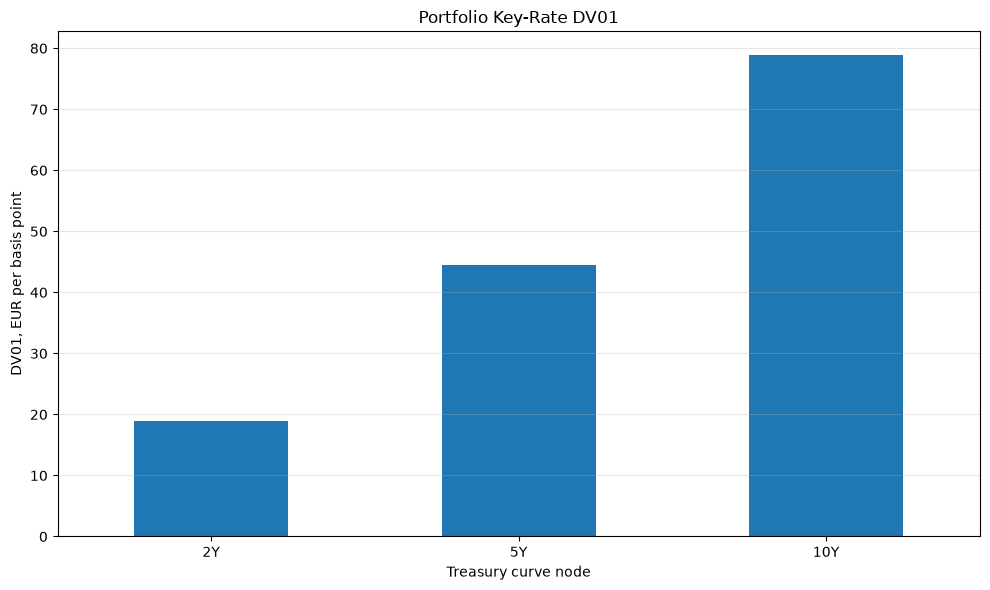

In [76]:
fig_key_rate_dv01, ax = plt.subplots(
    figsize=(10, 6)
)

key_rate_dv01[
    "key_rate_dv01_eur"
].plot(
    kind="bar",
    ax=ax,
)

ax.set_title(
    "Portfolio Key-Rate DV01"
)

ax.set_xlabel("Treasury curve node")
ax.set_ylabel("DV01, EUR per basis point")

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [77]:
curve_stress_scenarios = {
    "Parallel +100 bp": {
        "2Y": 100,
        "5Y": 100,
        "10Y": 100,
    },

    "Parallel -100 bp": {
        "2Y": -100,
        "5Y": -100,
        "10Y": -100,
    },

    "Bear steepener": {
        "2Y": 50,
        "5Y": 75,
        "10Y": 125,
    },

    "Bear flattener": {
        "2Y": 125,
        "5Y": 75,
        "10Y": 50,
    },

    "Bull steepener": {
        "2Y": -125,
        "5Y": -75,
        "10Y": -50,
    },

    "Bull flattener": {
        "2Y": -50,
        "5Y": -75,
        "10Y": -125,
    },

    "Short-end shock": {
        "2Y": 150,
        "5Y": 50,
        "10Y": 0,
    },

    "Long-end shock": {
        "2Y": 0,
        "5Y": 50,
        "10Y": 150,
    },
}

display(
    pd.DataFrame(
        curve_stress_scenarios
    ).T
)

,2Y,5Y,10Y
Parallel +100 bp,100,100,100
Parallel -100 bp,-100,-100,-100
Bear steepener,50,75,125
Bear flattener,125,75,50
Bull steepener,-125,-75,-50
Bull flattener,-50,-75,-125
Short-end shock,150,50,0
Long-end shock,0,50,150


In [78]:
curve_stress_records = []

for scenario_name, shocks in (
    curve_stress_scenarios.items()
):

    portfolio_exact_pnl = 0.0
    portfolio_linear_pnl = 0.0

    for row in bond_portfolio.itertuples():

        base_yield = float(
            latest_curve.loc[row.curve_node]
        )

        shock_bps = float(
            shocks[row.curve_node]
        )

        result = calculate_bond_shock_pnl(
            face_value=row.face_value_eur,
            coupon_rate=row.coupon_rate,
            maturity_years=row.maturity_years,
            base_yield=base_yield,
            shock_bps=shock_bps,
            payments_per_year=row.payments_per_year,
        )

        portfolio_exact_pnl += (
            result["exact_pnl_eur"]
        )

        portfolio_linear_pnl += (
            result["duration_pnl_eur"]
        )

        curve_stress_records.append(
            {
                "scenario": scenario_name,
                "bond": row.bond,
                "curve_node": row.curve_node,
                "shock_bps": shock_bps,
                "base_yield": base_yield,
                "shocked_yield": result[
                    "shocked_yield"
                ],
                "duration_pnl_eur": result[
                    "duration_pnl_eur"
                ],
                "duration_convexity_pnl_eur": result[
                    "duration_convexity_pnl_eur"
                ],
                "exact_pnl_eur": result[
                    "exact_pnl_eur"
                ],
            }
        )

curve_stress_detail = pd.DataFrame(
    curve_stress_records
)

display(curve_stress_detail.head())

,scenario,bond,curve_node,shock_bps,base_yield,shocked_yield,duration_pnl_eur,duration_convexity_pnl_eur,exact_pnl_eur
0,Parallel +100 bp,2Y Treasury,2Y,100.0,0.0415,0.0515,-1896.949330,-1873.949795,-1874.172090
1,Parallel +100 bp,5Y Treasury,5Y,100.0,0.0432,0.0532,-4445.801797,-4329.905224,-4332.103101
2,Parallel +100 bp,10Y Treasury,10Y,100.0,0.0463,0.0563,-7883.448977,-7507.503285,-7520.136520
3,Parallel -100 bp,2Y Treasury,2Y,-100.0,0.0415,0.0315,1896.949330,1919.948865,1920.174992
4,Parallel -100 bp,5Y Treasury,5Y,-100.0,0.0432,0.0332,4445.801797,4561.698370,4563.966597


In [79]:
curve_stress_summary = (
    curve_stress_detail
    .groupby("scenario")[
        [
            "duration_pnl_eur",
            "duration_convexity_pnl_eur",
            "exact_pnl_eur",
        ]
    ]
    .sum()
)

curve_stress_summary[
    "loss_pct_market_value"
] = (
    curve_stress_summary[
        "exact_pnl_eur"
    ]
    / fixed_income_market_value
)

curve_stress_summary = (
    curve_stress_summary
    .sort_values(
        "exact_pnl_eur",
        ascending=True,
    )
)

display(
    curve_stress_summary.style.format(
        {
            "duration_pnl_eur": "EUR {:+,.2f}",
            "duration_convexity_pnl_eur": "EUR {:+,.2f}",
            "exact_pnl_eur": "EUR {:+,.2f}",
            "loss_pct_market_value": "{:+.2%}",
        }
    )
)

,duration_pnl_eur,duration_convexity_pnl_eur,exact_pnl_eur,loss_pct_market_value
scenario,,,,
Parallel +100 bp,"EUR -14,226.20","EUR -13,711.36","EUR -13,726.41",-4.60%
Bear steepener,"EUR -14,137.14","EUR -13,478.78","EUR -13,504.25",-4.53%
Long-end shock,"EUR -14,048.07","EUR -13,173.22","EUR -13,215.57",-4.43%
Bear flattener,"EUR -9,647.26","EUR -9,452.15","EUR -9,455.11",-3.17%
Short-end shock,"EUR -5,068.32","EUR -4,987.60","EUR -4,988.63",-1.67%
Bull steepener,"EUR +9,647.26","EUR +9,842.38","EUR +9,845.42",+3.30%
Parallel -100 bp,"EUR +14,226.20","EUR +14,741.04","EUR +14,756.88",+4.95%
Bull flattener,"EUR +14,137.14","EUR +14,795.49","EUR +14,822.73",+4.97%


In [80]:
worst_curve_stress = (
    curve_stress_summary
    .iloc[0]
)

worst_curve_stress_name = (
    curve_stress_summary.index[0]
)

print(
    f"Worst curve scenario: "
    f"{worst_curve_stress_name}"
)

print(
    f"Exact portfolio P&L: "
    f"EUR "
    f"{worst_curve_stress['exact_pnl_eur']:+,.2f}"
)

print(
    f"Loss as percentage of market value: "
    f"{worst_curve_stress['loss_pct_market_value']:+.2%}"
)

Worst curve scenario: Parallel +100 bp
Exact portfolio P&L: EUR -13,726.41
Loss as percentage of market value: -4.60%


In [81]:
worst_curve_stress_detail = (
    curve_stress_detail.loc[
        curve_stress_detail["scenario"]
        == worst_curve_stress_name
    ]
    .copy()
)

worst_curve_total_pnl = (
    worst_curve_stress_detail[
        "exact_pnl_eur"
    ].sum()
)

worst_curve_stress_detail[
    "pnl_contribution_pct"
] = (
    worst_curve_stress_detail[
        "exact_pnl_eur"
    ]
    / worst_curve_total_pnl
)

display(
    worst_curve_stress_detail[
        [
            "bond",
            "curve_node",
            "shock_bps",
            "exact_pnl_eur",
            "pnl_contribution_pct",
        ]
    ].style.format(
        {
            "shock_bps": "{:+.0f}",
            "exact_pnl_eur": "EUR {:+,.2f}",
            "pnl_contribution_pct": "{:.2%}",
        }
    )
)

,bond,curve_node,shock_bps,exact_pnl_eur,pnl_contribution_pct
0,2Y Treasury,2Y,+100,"EUR -1,874.17",13.65%
1,5Y Treasury,5Y,+100,"EUR -4,332.10",31.56%
2,10Y Treasury,10Y,+100,"EUR -7,520.14",54.79%


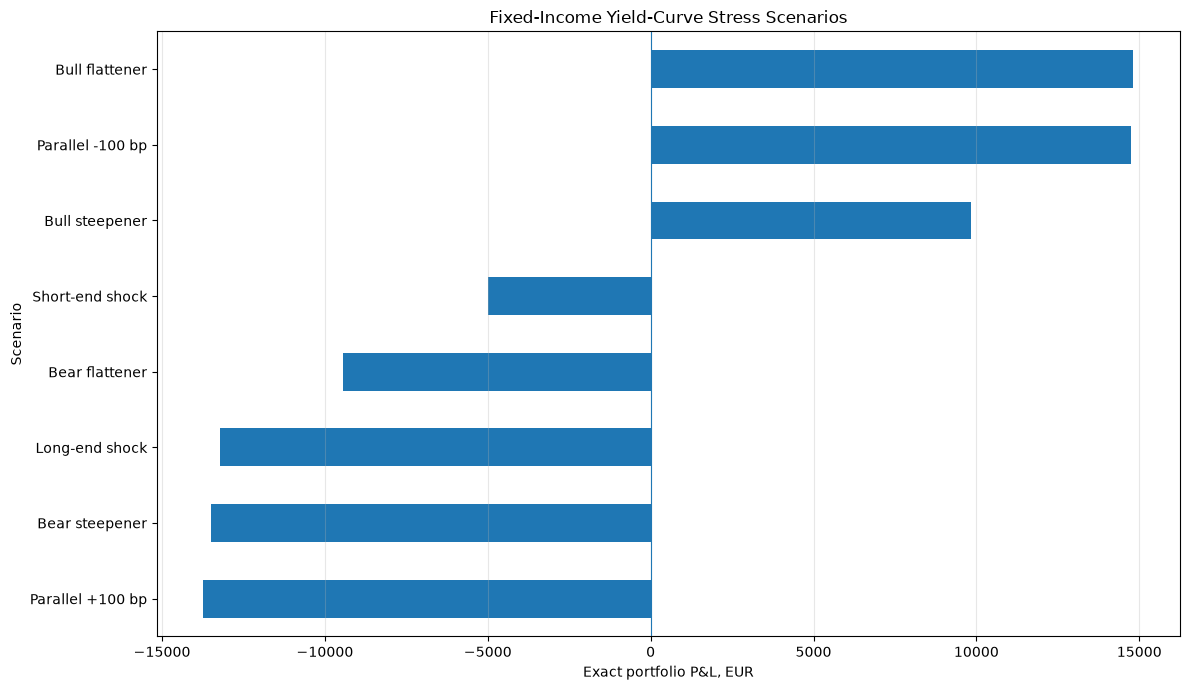

In [82]:
fig_curve_stresses, ax = plt.subplots(
    figsize=(12, 7)
)

curve_stress_summary[
    "exact_pnl_eur"
].sort_values().plot(
    kind="barh",
    ax=ax,
)

ax.axvline(
    0,
    linewidth=0.8,
)

ax.set_title(
    "Fixed-Income Yield-Curve Stress Scenarios"
)

ax.set_xlabel("Exact portfolio P&L, EUR")
ax.set_ylabel("Scenario")

ax.grid(
    axis="x",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [83]:
key_rate_dv01.to_csv(
    TABLES_DIR
    / "key_rate_dv01.csv",
    index=True,
)

curve_stress_detail.to_csv(
    TABLES_DIR
    / "yield_curve_stress_detail.csv",
    index=False,
)

curve_stress_summary.to_csv(
    TABLES_DIR
    / "yield_curve_stress_summary.csv",
    index=True,
)

worst_curve_stress_detail.to_csv(
    TABLES_DIR
    / "worst_curve_stress_contributions.csv",
    index=False,
)

fig_key_rate_dv01.savefig(
    CHARTS_DIR
    / "key_rate_dv01.png",
    dpi=300,
    bbox_inches="tight",
)

fig_curve_stresses.savefig(
    CHARTS_DIR
    / "yield_curve_stress_scenarios.png",
    dpi=300,
    bbox_inches="tight",
)

print(
    "Key-rate and non-parallel stress outputs saved."
)

Key-rate and non-parallel stress outputs saved.


### Key-rate and curve-stress interpretation

The fixed-income portfolio is materially concentrated in longer-dated
interest-rate risk.

The 10-year Treasury node contributes approximately 55.4% of total portfolio
DV01, despite the 10-year bond representing only one-third of the portfolio's
face value. The 5-year node contributes approximately 31.3%, while the 2-year
node contributes approximately 13.3%.

Among the predefined yield-curve scenarios, the worst result is a parallel
100-basis-point increase in yields. Exact full revaluation produces a loss of
approximately EUR 13,726, equivalent to approximately 4.6% of the fixed-income
portfolio's current market value.

The bear-steepener and long-end shock scenarios also produce substantial
losses because the portfolio is concentrated in the 10-year maturity.

The gain from a 100-basis-point decline in yields is larger than the loss from
an equivalent increase. This asymmetry reflects positive bond convexity and
demonstrates why full revaluation becomes increasingly important for larger
rate movements.

## 6. Historical yield-curve VaR

Historical fixed-income VaR is calculated by applying observed historical
daily changes in Treasury yields to the current bond portfolio.

For each historical scenario:

1. The observed daily changes in the 2-year, 5-year and 10-year Treasury yields
   are extracted.
2. Those yield changes are applied to today's Treasury curve.
3. Each bond is fully repriced under the shocked curve.
4. Scenario-level portfolio P&L is calculated.
5. VaR and Expected Shortfall are estimated from the resulting P&L
   distribution.

This differs from the earlier ETF-based rates exposure because the underlying
interest-rate risk factors are now explicit yield-curve movements.

In [84]:
FIXED_INCOME_VAR_LOOKBACK = 500
FIXED_INCOME_CONFIDENCE_LEVEL = 0.99
FIXED_INCOME_TAIL_PROBABILITY = (
    1 - FIXED_INCOME_CONFIDENCE_LEVEL
)

RATE_NODES = [
    "2Y",
    "5Y",
    "10Y",
]

historical_yield_changes = (
    treasury_yields_complete[RATE_NODES]
    .diff()
    .dropna()
)

recent_yield_changes = (
    historical_yield_changes
    .iloc[-FIXED_INCOME_VAR_LOOKBACK:]
    .copy()
)

# Convert decimal yield changes into basis points.
recent_yield_changes_bps = (
    recent_yield_changes
    * 10_000
)

print(
    f"Historical rate scenarios: "
    f"{len(recent_yield_changes_bps):,}"
)

print(
    f"Scenario period: "
    f"{recent_yield_changes_bps.index.min().date()} "
    f"to "
    f"{recent_yield_changes_bps.index.max().date()}"
)

display(
    recent_yield_changes_bps.describe().style.format(
        "{:+.2f}"
    )
)

Historical rate scenarios: 500
Scenario period: 2024-08-13 to 2026-08-13


,2Y,5Y,10Y
count,+500.00,+500.00,+500.00
mean,+0.03,+0.11,+0.15
std,+5.21,+5.23,+4.78
min,-25.00,-20.00,-14.00
25%,-3.00,-3.00,-3.00
50%,+0.00,+0.00,+0.00
75%,+3.00,+3.00,+3.00
max,+23.00,+19.00,+16.00


In [85]:
yield_change_correlation = (
    recent_yield_changes_bps.corr()
)

display(
    yield_change_correlation.style.format(
        "{:.3f}"
    )
)

,2Y,5Y,10Y
2Y,1.000,0.911,0.788
5Y,0.911,1.000,0.938
10Y,0.788,0.938,1.000


### Yield-curve dependence

Treasury maturities generally move together, but their movements are not
perfectly correlated.

Historical curve scenarios therefore contain both:

- Level shifts, where several maturities move in the same direction
- Shape changes, where short-, medium- and long-term yields move by different
  amounts

Using the full historical vector of yield changes preserves these observed
cross-maturity relationships.

In [86]:
def revalue_bond_portfolio_from_curve_shock(
    yield_changes_bps: pd.Series,
    base_curve: pd.Series,
    bond_portfolio: pd.DataFrame,
) -> tuple[float, pd.DataFrame]:
    """
    Fully revalue the bond portfolio after a historical curve shock.
    """
    detail_records = []

    total_pnl = 0.0

    for row in bond_portfolio.itertuples():

        node = row.curve_node

        base_yield = float(
            base_curve.loc[node]
        )

        shock_bps = float(
            yield_changes_bps.loc[node]
        )

        shocked_yield = (
            base_yield
            + shock_bps / 10_000
        )

        base_price = price_fixed_coupon_bond(
            face_value=row.face_value_eur,
            coupon_rate=row.coupon_rate,
            maturity_years=row.maturity_years,
            yield_to_maturity=base_yield,
            payments_per_year=row.payments_per_year,
        )

        shocked_price = price_fixed_coupon_bond(
            face_value=row.face_value_eur,
            coupon_rate=row.coupon_rate,
            maturity_years=row.maturity_years,
            yield_to_maturity=shocked_yield,
            payments_per_year=row.payments_per_year,
        )

        pnl = (
            shocked_price
            - base_price
        )

        total_pnl += pnl

        detail_records.append(
            {
                "bond": row.bond,
                "curve_node": node,
                "shock_bps": shock_bps,
                "base_yield": base_yield,
                "shocked_yield": shocked_yield,
                "base_price_eur": base_price,
                "shocked_price_eur": shocked_price,
                "pnl_eur": pnl,
            }
        )

    return (
        float(total_pnl),
        pd.DataFrame(detail_records),
    )

In [87]:
historical_rate_scenario_records = []

for scenario_date, yield_change_row in (
    recent_yield_changes_bps.iterrows()
):

    portfolio_scenario_pnl, _ = (
        revalue_bond_portfolio_from_curve_shock(
            yield_changes_bps=yield_change_row,
            base_curve=latest_curve,
            bond_portfolio=bond_portfolio,
        )
    )

    historical_rate_scenario_records.append(
        {
            "scenario_date": scenario_date,
            "change_2y_bps": yield_change_row["2Y"],
            "change_5y_bps": yield_change_row["5Y"],
            "change_10y_bps": yield_change_row["10Y"],
            "portfolio_pnl_eur": portfolio_scenario_pnl,
        }
    )

historical_rate_scenarios = (
    pd.DataFrame(
        historical_rate_scenario_records
    )
    .set_index("scenario_date")
)

assert len(historical_rate_scenarios) == 500

display(
    historical_rate_scenarios.head()
)

,change_2y_bps,change_5y_bps,change_10y_bps,portfolio_pnl_eur
scenario_date,,,,
2024-08-13,-8.0,-7.0,-5.0,858.791982
2024-08-14,1.0,-1.0,-2.0,183.321878
2024-08-15,14.0,12.0,9.0,-1503.428574
2024-08-16,-2.0,-2.0,-3.0,363.752772
2024-08-19,0.0,-2.0,-3.0,325.804584


In [88]:
def calculate_empirical_var_es(
    pnl_series: pd.Series,
    confidence_level: float,
) -> dict:
    """
    Calculate empirical VaR and Expected Shortfall using equally
    weighted historical scenarios.
    """
    clean_pnl = (
        pd.Series(pnl_series)
        .dropna()
        .astype(float)
    )

    if clean_pnl.empty:
        raise ValueError(
            "P&L series cannot be empty."
        )

    if not 0 < confidence_level < 1:
        raise ValueError(
            "confidence_level must lie between zero and one."
        )

    sorted_pnl = np.sort(
        clean_pnl.to_numpy()
    )

    observations = len(sorted_pnl)
    tail_probability = (
        1 - confidence_level
    )

    scenario_weight = (
        1 / observations
    )

    cumulative_weights = (
        np.arange(
            1,
            observations + 1
        )
        * scenario_weight
    )

    boundary_position = int(
        np.searchsorted(
            cumulative_weights,
            tail_probability,
            side="left",
        )
    )

    var_boundary_pnl = float(
        sorted_pnl[boundary_position]
    )

    var_eur = -var_boundary_pnl

    cumulative_weight_before = (
        np.arange(observations)
        * scenario_weight
    )

    allocated_weights = np.clip(
        tail_probability
        - cumulative_weight_before,
        0.0,
        scenario_weight,
    )

    expected_shortfall_eur = -float(
        np.sum(
            sorted_pnl
            * allocated_weights
        )
        / allocated_weights.sum()
    )

    return {
        "observations": observations,
        "confidence_level": confidence_level,
        "effective_tail_scenarios": (
            observations
            * tail_probability
        ),
        "var_eur": var_eur,
        "expected_shortfall_eur": (
            expected_shortfall_eur
        ),
    }

In [89]:
fixed_income_historical_risk = (
    calculate_empirical_var_es(
        pnl_series=historical_rate_scenarios[
            "portfolio_pnl_eur"
        ],
        confidence_level=(
            FIXED_INCOME_CONFIDENCE_LEVEL
        ),
    )
)

fixed_income_historical_risk_table = (
    pd.DataFrame(
        {
            "model": [
                "Historical Full Revaluation"
            ],
            **{
                key: [value]
                for key, value
                in fixed_income_historical_risk.items()
            },
        }
    )
)

display(
    fixed_income_historical_risk_table.style.format(
        {
            "confidence_level": "{:.0%}",
            "effective_tail_scenarios": "{:.2f}",
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
        }
    )
)

,model,observations,confidence_level,effective_tail_scenarios,var_eur,expected_shortfall_eur
0,Historical Full Revaluation,500,99%,5.00,"EUR 1,701.96","EUR 1,908.28"


In [90]:
worst_historical_rate_date = (
    historical_rate_scenarios[
        "portfolio_pnl_eur"
    ].idxmin()
)

worst_historical_rate_scenario = (
    historical_rate_scenarios.loc[
        worst_historical_rate_date
    ]
)

print(
    f"Worst historical rate scenario: "
    f"{worst_historical_rate_date.date()}"
)

print(
    f"2Y change: "
    f"{worst_historical_rate_scenario['change_2y_bps']:+.2f} bp"
)

print(
    f"5Y change: "
    f"{worst_historical_rate_scenario['change_5y_bps']:+.2f} bp"
)

print(
    f"10Y change: "
    f"{worst_historical_rate_scenario['change_10y_bps']:+.2f} bp"
)

print(
    f"Portfolio P&L: "
    f"EUR "
    f"{worst_historical_rate_scenario['portfolio_pnl_eur']:+,.2f}"
)

Worst historical rate scenario: 2024-10-04
2Y change: +23.00 bp
5Y change: +19.00 bp
10Y change: +13.00 bp
Portfolio P&L: EUR -2,294.14


In [91]:
worst_shock_vector = pd.Series(
    {
        "2Y": worst_historical_rate_scenario[
            "change_2y_bps"
        ],
        "5Y": worst_historical_rate_scenario[
            "change_5y_bps"
        ],
        "10Y": worst_historical_rate_scenario[
            "change_10y_bps"
        ],
    }
)

(
    worst_historical_exact_pnl,
    worst_historical_bond_detail,
) = revalue_bond_portfolio_from_curve_shock(
    yield_changes_bps=worst_shock_vector,
    base_curve=latest_curve,
    bond_portfolio=bond_portfolio,
)

worst_historical_bond_detail[
    "loss_contribution_pct"
] = (
    worst_historical_bond_detail[
        "pnl_eur"
    ]
    / worst_historical_exact_pnl
)

display(
    worst_historical_bond_detail.style.format(
        {
            "shock_bps": "{:+.2f}",
            "base_yield": "{:.3%}",
            "shocked_yield": "{:.3%}",
            "base_price_eur": "EUR {:,.2f}",
            "shocked_price_eur": "EUR {:,.2f}",
            "pnl_eur": "EUR {:+,.2f}",
            "loss_contribution_pct": "{:.2%}",
        }
    )
)

,bond,curve_node,shock_bps,base_yield,shocked_yield,base_price_eur,shocked_price_eur,pnl_eur,loss_contribution_pct
0,2Y Treasury,2Y,+23.00,4.150%,4.380%,"EUR 99,714.94","EUR 99,279.85",EUR -435.08,18.97%
1,5Y Treasury,5Y,+19.00,4.320%,4.510%,"EUR 99,688.23","EUR 98,847.69",EUR -840.53,36.64%
2,10Y Treasury,10Y,+13.00,4.630%,4.760%,"EUR 98,968.77","EUR 97,950.25","EUR -1,018.52",44.40%


In [92]:
key_rate_dv01_vector = (
    key_rate_dv01
    .reindex(RATE_NODES)[
        "key_rate_dv01_eur"
    ]
    .to_numpy(dtype=float)
)

yield_change_covariance_bps = (
    recent_yield_changes_bps[
        RATE_NODES
    ]
    .cov()
    .to_numpy(dtype=float)
)

linear_pnl_variance = float(
    key_rate_dv01_vector
    @ yield_change_covariance_bps
    @ key_rate_dv01_vector
)

linear_pnl_volatility = np.sqrt(
    max(
        linear_pnl_variance,
        0.0,
    )
)

fixed_income_normal_var = (
    norm.ppf(
        FIXED_INCOME_CONFIDENCE_LEVEL
    )
    * linear_pnl_volatility
)

fixed_income_normal_es = (
    linear_pnl_volatility
    * norm.pdf(
        norm.ppf(
            FIXED_INCOME_CONFIDENCE_LEVEL
        )
    )
    / FIXED_INCOME_TAIL_PROBABILITY
)

print(
    f"Key-rate linear P&L volatility: "
    f"EUR {linear_pnl_volatility:,.2f}"
)

print(
    f"99% Parametric Normal VaR: "
    f"EUR {fixed_income_normal_var:,.2f}"
)

print(
    f"99% Parametric Normal ES: "
    f"EUR {fixed_income_normal_es:,.2f}"
)

Key-rate linear P&L volatility: EUR 686.30
99% Parametric Normal VaR: EUR 1,596.57
99% Parametric Normal ES: EUR 1,829.14


In [93]:
fixed_income_var_comparison = pd.DataFrame(
    {
        "model": [
            "Historical Full Revaluation",
            "Parametric Key-Rate Normal",
        ],
        "var_eur": [
            fixed_income_historical_risk[
                "var_eur"
            ],
            fixed_income_normal_var,
        ],
        "expected_shortfall_eur": [
            fixed_income_historical_risk[
                "expected_shortfall_eur"
            ],
            fixed_income_normal_es,
        ],
    }
)

fixed_income_var_comparison[
    "var_pct_market_value"
] = (
    fixed_income_var_comparison[
        "var_eur"
    ]
    / fixed_income_market_value
)

fixed_income_var_comparison[
    "es_pct_market_value"
] = (
    fixed_income_var_comparison[
        "expected_shortfall_eur"
    ]
    / fixed_income_market_value
)

display(
    fixed_income_var_comparison.style.format(
        {
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
            "var_pct_market_value": "{:.2%}",
            "es_pct_market_value": "{:.2%}",
        }
    )
)

,model,var_eur,expected_shortfall_eur,var_pct_market_value,es_pct_market_value
0,Historical Full Revaluation,"EUR 1,701.96","EUR 1,908.28",0.57%,0.64%
1,Parametric Key-Rate Normal,"EUR 1,596.57","EUR 1,829.14",0.54%,0.61%


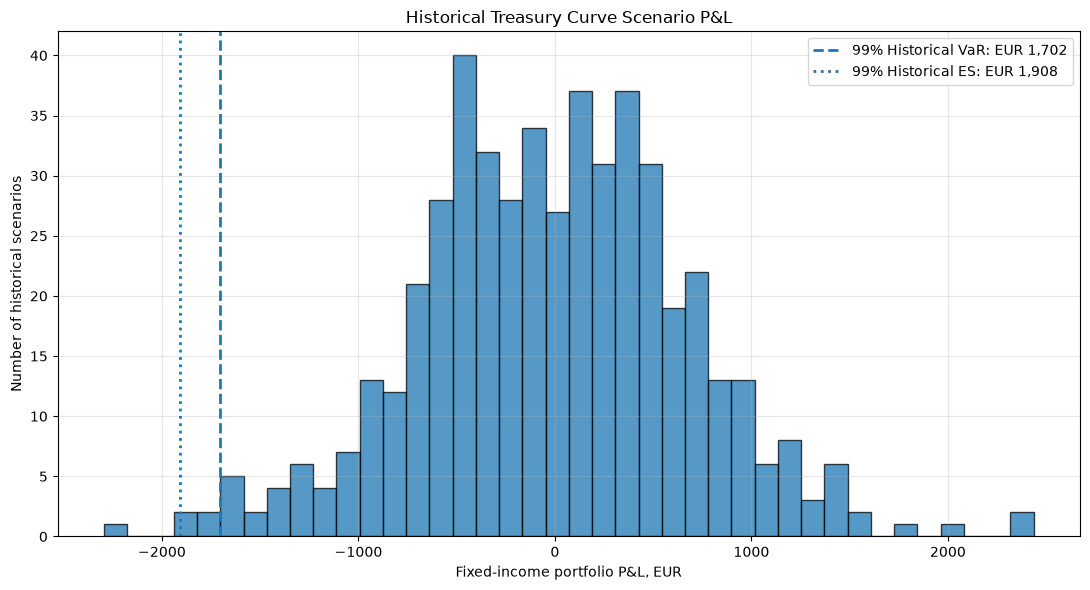

In [94]:
fig_fixed_income_historical_var, ax = plt.subplots(
    figsize=(11, 6)
)

ax.hist(
    historical_rate_scenarios[
        "portfolio_pnl_eur"
    ],
    bins=40,
    edgecolor="black",
    alpha=0.75,
)

ax.axvline(
    -fixed_income_historical_risk[
        "var_eur"
    ],
    linestyle="--",
    linewidth=2,
    label=(
        "99% Historical VaR: "
        f"EUR "
        f"{fixed_income_historical_risk['var_eur']:,.0f}"
    ),
)

ax.axvline(
    -fixed_income_historical_risk[
        "expected_shortfall_eur"
    ],
    linestyle=":",
    linewidth=2,
    label=(
        "99% Historical ES: "
        f"EUR "
        f"{fixed_income_historical_risk['expected_shortfall_eur']:,.0f}"
    ),
)

ax.set_title(
    "Historical Treasury Curve Scenario P&L"
)

ax.set_xlabel(
    "Fixed-income portfolio P&L, EUR"
)

ax.set_ylabel(
    "Number of historical scenarios"
)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

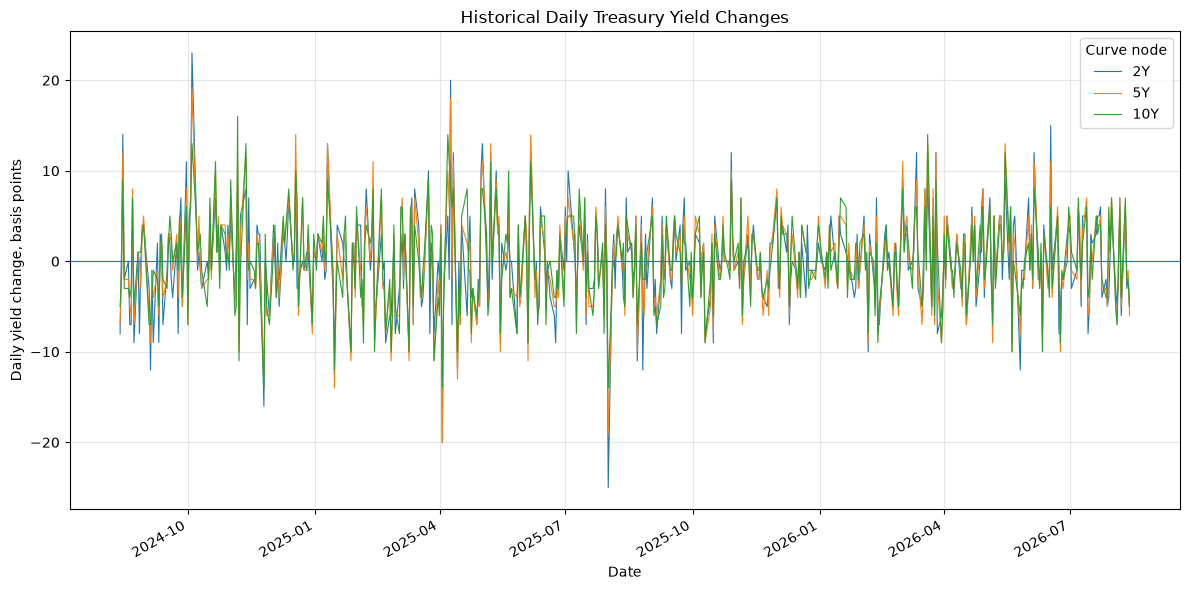

In [95]:
fig_historical_curve_changes, ax = plt.subplots(
    figsize=(12, 6)
)

recent_yield_changes_bps[
    RATE_NODES
].plot(
    ax=ax,
    linewidth=0.8,
)

ax.axhline(
    0,
    linewidth=0.8,
)

ax.set_title(
    "Historical Daily Treasury Yield Changes"
)

ax.set_xlabel("Date")
ax.set_ylabel("Daily yield change, basis points")

ax.legend(
    title="Curve node"
)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [96]:
historical_rate_scenarios.to_csv(
    TABLES_DIR
    / "historical_treasury_curve_scenarios.csv",
    index=True,
)

fixed_income_historical_risk_table.to_csv(
    TABLES_DIR
    / "fixed_income_historical_var_es.csv",
    index=False,
)

fixed_income_var_comparison.to_csv(
    TABLES_DIR
    / "fixed_income_var_comparison.csv",
    index=False,
)

worst_historical_bond_detail.to_csv(
    TABLES_DIR
    / "worst_historical_rate_scenario_detail.csv",
    index=False,
)

yield_change_correlation.to_csv(
    TABLES_DIR
    / "treasury_yield_change_correlation.csv",
    index=True,
)

fig_fixed_income_historical_var.savefig(
    CHARTS_DIR
    / "fixed_income_historical_var_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

fig_historical_curve_changes.savefig(
    CHARTS_DIR
    / "historical_treasury_yield_changes.png",
    dpi=300,
    bbox_inches="tight",
)

print(
    "Historical fixed-income VaR outputs saved."
)

Historical fixed-income VaR outputs saved.


## 7. Day 5 conclusions

The fixed-income module replaces the original government-bond return proxy
with an instrument-level interest-rate risk framework.

The portfolio contains illustrative 2-year, 5-year and 10-year fixed-rate
bonds and is valued using Treasury benchmark yields. Duration, convexity,
DV01 and key-rate DV01 are calculated at bond and portfolio level.

Interest-rate risk is materially concentrated in the long end of the curve.
The 10-year node contributes approximately 55% of portfolio DV01, despite the
10-year bond representing only one-third of portfolio face value. The 5-year
and 2-year nodes contribute approximately 31% and 13%, respectively.

Under a +100 basis-point parallel yield increase, exact full revaluation
produces a loss of approximately EUR 13,726, or 4.6% of fixed-income market
value. The 10-year bond contributes approximately 55% of this loss.

Duration provides a useful approximation for small rate movements but becomes
increasingly inaccurate as shocks increase. Adding convexity reduces the mean
absolute approximation error from approximately EUR 685 to EUR 35 across the
tested parallel-rate scenarios.

Historical yield changes also show strong but imperfect dependence across
Treasury maturities. The 5-year and 10-year daily yield changes have a
correlation of approximately 0.94, while the 2-year and 10-year correlation is
approximately 0.79. Historical full-revaluation scenarios therefore preserve
both curve-level and curve-shape movements.

Using 500 historical Treasury curve scenarios, the fixed-income portfolio has
a one-day 99% Historical Full-Revaluation VaR of approximately EUR 1,702 and
Expected Shortfall of approximately EUR 1,908.

The Parametric Key-Rate Normal model produces a lower VaR of approximately
EUR 1,597 and Expected Shortfall of approximately EUR 1,829. Historical
full revaluation therefore produces a more conservative tail-risk estimate,
reflecting empirical curve movements and nonlinear repricing.

The worst historical scenario in the 500-day window occurred on 4 October
2024. The 2-year, 5-year and 10-year yields increased by approximately 23,
19 and 13 basis points, respectively, producing a portfolio loss of
approximately EUR 2,294.

The analysis demonstrates the distinction between statistical risk measures
and stress testing. Historical one-day VaR is approximately EUR 1,702, while
a hypothetical +100 basis-point parallel shock produces a loss of more than
EUR 13,700.

Important limitations remain. The bonds are illustrative rather than actual
Treasury securities, each bond is mapped directly to a single maturity node,
credit and liquidity spreads are excluded, and EUR reporting values are used
without separate USD/EUR translation.